In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset

In [2]:
dp=pd.read_csv(r"C:\Users\Raushan kumar\Downloads\credit_risk_dataset.csv")

In [3]:
dp

,Age,Income,Loan_Amount,Credit_Score,Employment_Years,Education_Level,Housing_Status,Default
0,59,52154.0,11276,823,15,Bachelors,Own,0
1,49,116646.0,43663,315,5,PhD,Own,0
2,35,61157.0,18994,428,8,Masters,Own,1
3,63,52154.0,28499,408,26,Bachelors,Rent,0
4,28,148876.0,28040,832,3,Masters,Own,1
...,...,...,...,...,...,...,...,...
995,53,44519.0,7307,433,22,PhD,Rent,1
996,22,107487.0,44901,582,7,High School,Own,1
997,34,102870.0,16205,372,29,Masters,Rent,0
998,60,66197.0,10906,780,24,PhD,Own,0


In [4]:
dp.shape

(1000, 8)

In [5]:
pd.set_option('display.max_columns',None)

In [6]:
dp.head()

,Age,Income,Loan_Amount,Credit_Score,Employment_Years,Education_Level,Housing_Status,Default
0,59,52154.0,11276,823,15,Bachelors,Own,0
1,49,116646.0,43663,315,5,PhD,Own,0
2,35,61157.0,18994,428,8,Masters,Own,1
3,63,52154.0,28499,408,26,Bachelors,Rent,0
4,28,148876.0,28040,832,3,Masters,Own,1


In [7]:
pd.set_option('display.max_rows',None)

In [8]:
dp.head()

,Age,Income,Loan_Amount,Credit_Score,Employment_Years,Education_Level,Housing_Status,Default
0,59,52154.0,11276,823,15,Bachelors,Own,0
1,49,116646.0,43663,315,5,PhD,Own,0
2,35,61157.0,18994,428,8,Masters,Own,1
3,63,52154.0,28499,408,26,Bachelors,Rent,0
4,28,148876.0,28040,832,3,Masters,Own,1


# Check Missing Values

In [9]:
dp.isnull().sum()

Age                  0
Income              15
Loan_Amount          0
Credit_Score         0
Employment_Years     0
Education_Level      0
Housing_Status       0
Default              0
dtype: int64

# Fill Missing Values

In [10]:
dp['Income'] = dp['Income'].fillna(dp['Income'].median())

# Check Missing Values Again

In [11]:
dp.isnull().sum()

Age                 0
Income              0
Loan_Amount         0
Credit_Score        0
Employment_Years    0
Education_Level     0
Housing_Status      0
Default             0
dtype: int64

# Encoding

In [12]:
cat_cols = dp.select_dtypes(include=['object']).columns
dp = pd.get_dummies(dp,columns=cat_cols,drop_first=True)

C:\Users\Raushan kumar\AppData\Local\Temp\ipykernel_18780\2406474653.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = dp.select_dtypes(include=['object']).columns


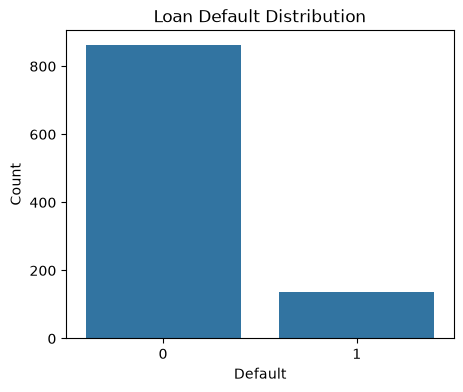

In [13]:
plt.figure(figsize=(5,4))
sns.countplot(x='Default', data=dp)
plt.title("Loan Default Distribution")
plt.xlabel("Default")
plt.ylabel("Count")
plt.show()

In [14]:
print(dp['Default'].value_counts())

Default
0    862
1    138
Name: count, dtype: int64


# Features and Target

In [15]:
X = dp.drop(columns=['Default'])
y = dp['Default']

# Train Test Split

In [16]:
from sklearn.model_selection import train_test_split

In [17]:
X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=.2,random_state=42,stratify=y)

In [18]:
X_train.shape

(800, 10)

In [19]:
X_test.shape

(200, 10)

# Feature Scaling

In [20]:
from sklearn.preprocessing import StandardScaler

In [21]:
ss=StandardScaler()

In [22]:
arr=ss.fit_transform(X_train)

In [23]:
arr1=ss.transform(X_test)

In [24]:
X_train_scale=pd.DataFrame(arr, columns=X_train.columns)

In [25]:
X_train_scale.head()

,Age,Income,Loan_Amount,Credit_Score,Employment_Years,Education_Level_High School,Education_Level_Masters,Education_Level_PhD,Housing_Status_Own,Housing_Status_Rent
0,0.116819,-1.187103,0.755277,0.037253,1.002335,-0.542677,-0.604308,1.703655,1.420869,-0.685994
1,0.037887,-1.595825,0.678160,-0.875842,-0.977873,-0.542677,-0.604308,1.703655,-0.703795,1.457738
2,1.695458,-1.448030,-1.480628,-1.370436,-0.395459,1.842717,-0.604308,-0.586973,-0.703795,-0.685994
3,1.458663,0.676883,-0.638863,-1.104116,-0.162494,-0.542677,-0.604308,-0.586973,-0.703795,-0.685994
4,1.379731,0.551170,0.931889,-0.273453,-1.793253,-0.542677,-0.604308,-0.586973,-0.703795,1.457738


In [26]:
X_train_scale.isnull().sum()

Age                            0
Income                         0
Loan_Amount                    0
Credit_Score                   0
Employment_Years               0
Education_Level_High School    0
Education_Level_Masters        0
Education_Level_PhD            0
Housing_Status_Own             0
Housing_Status_Rent            0
dtype: int64

In [27]:
X_train_scale.shape

(800, 10)

In [28]:
X_test_scale=pd.DataFrame(arr1, columns=X_test.columns)

In [29]:
X_test_scale.head()

,Age,Income,Loan_Amount,Credit_Score,Employment_Years,Education_Level_High School,Education_Level_Masters,Education_Level_PhD,Housing_Status_Own,Housing_Status_Rent
0,-0.593568,-0.584598,-0.685311,-0.945593,-0.861391,-0.542677,1.654786,-0.586973,1.420869,-0.685994
1,0.274683,0.252668,1.699434,1.463965,0.070472,-0.542677,-0.604308,1.703655,-0.703795,1.457738
2,1.458663,0.676883,-0.852424,1.337146,0.885852,1.842717,-0.604308,-0.586973,-0.703795,-0.685994
3,-0.119977,-1.059648,0.511449,-0.983638,-1.560287,1.842717,-0.604308,-0.586973,1.420869,-0.685994
4,1.300799,-1.397495,-0.341263,-0.571477,-1.443805,-0.542677,-0.604308,-0.586973,-0.703795,1.457738


In [30]:
X_test_scale.isnull().sum()

Age                            0
Income                         0
Loan_Amount                    0
Credit_Score                   0
Employment_Years               0
Education_Level_High School    0
Education_Level_Masters        0
Education_Level_PhD            0
Housing_Status_Own             0
Housing_Status_Rent            0
dtype: int64

In [31]:
X_test_scale.shape

(200, 10)

# Logistic Regression

In [32]:
from sklearn.linear_model import LogisticRegression

In [33]:
lr = LogisticRegression(class_weight='balanced',max_iter=1000,random_state=42)

In [34]:
lr.fit(X_train_scale, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default 

# Prediction

In [35]:
y_pred = lr.predict(X_test_scale)

In [36]:
y_pred

array([1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1,
       0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1,
       1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1,
       0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1,
       1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1,
       0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
       1, 1])

In [37]:
lr.score(X_test_scale,y_test)

0.57

# Model Evaluation

In [38]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report,roc_curve,auc

In [39]:
print("Train Score:", lr.score(X_train_scale, y_train))
print("Test Score :", lr.score(X_test_scale, y_test))

Train Score: 0.58125
Test Score : 0.57


In [40]:
print("Accuracy Score :", accuracy_score(y_test, y_pred))
print("Precision      :", precision_score(y_test, y_pred))
print("Recall         :", recall_score(y_test, y_pred))
print("F1 Score       :", f1_score(y_test, y_pred))

Accuracy Score : 0.57
Precision      : 0.15476190476190477
Recall         : 0.4642857142857143
F1 Score       : 0.23214285714285715


# Confusion Matrix

In [41]:
cm = confusion_matrix(y_test, y_pred)

In [42]:
print("Confusion Matrix")
print(cm)

Confusion Matrix
[[101  71]
 [ 15  13]]


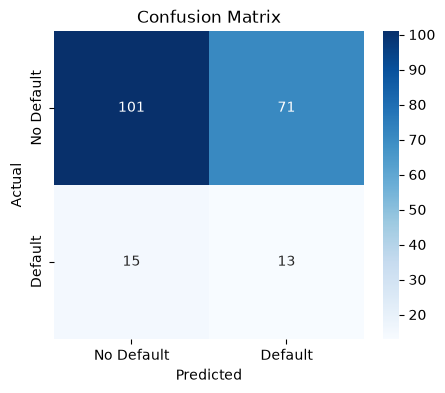

In [43]:
plt.figure(figsize=(5,4))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=['No Default','Default'],yticklabels=['No Default','Default'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [44]:
print("Classification Report")
print(classification_report(y_test, y_pred))

Classification Report
              precision    recall  f1-score   support

           0       0.87      0.59      0.70       172
           1       0.15      0.46      0.23        28

    accuracy                           0.57       200
   macro avg       0.51      0.53      0.47       200
weighted avg       0.77      0.57      0.64       200



# ROC Curve

In [45]:
y_prob = lr.predict_proba(X_test_scale)[:,1]

In [46]:
fpr, tpr, threshold = roc_curve(y_test, y_prob)

In [47]:
roc_auc = auc(fpr, tpr)

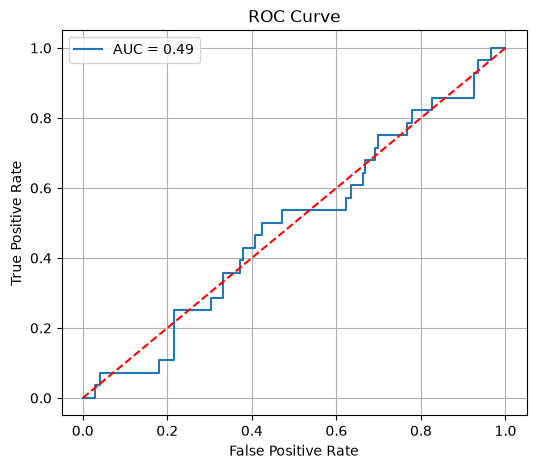

In [48]:
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label="AUC = %0.2f" % roc_auc)
plt.plot([0,1],[0,1],'r--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)

# Correlation Heatmap

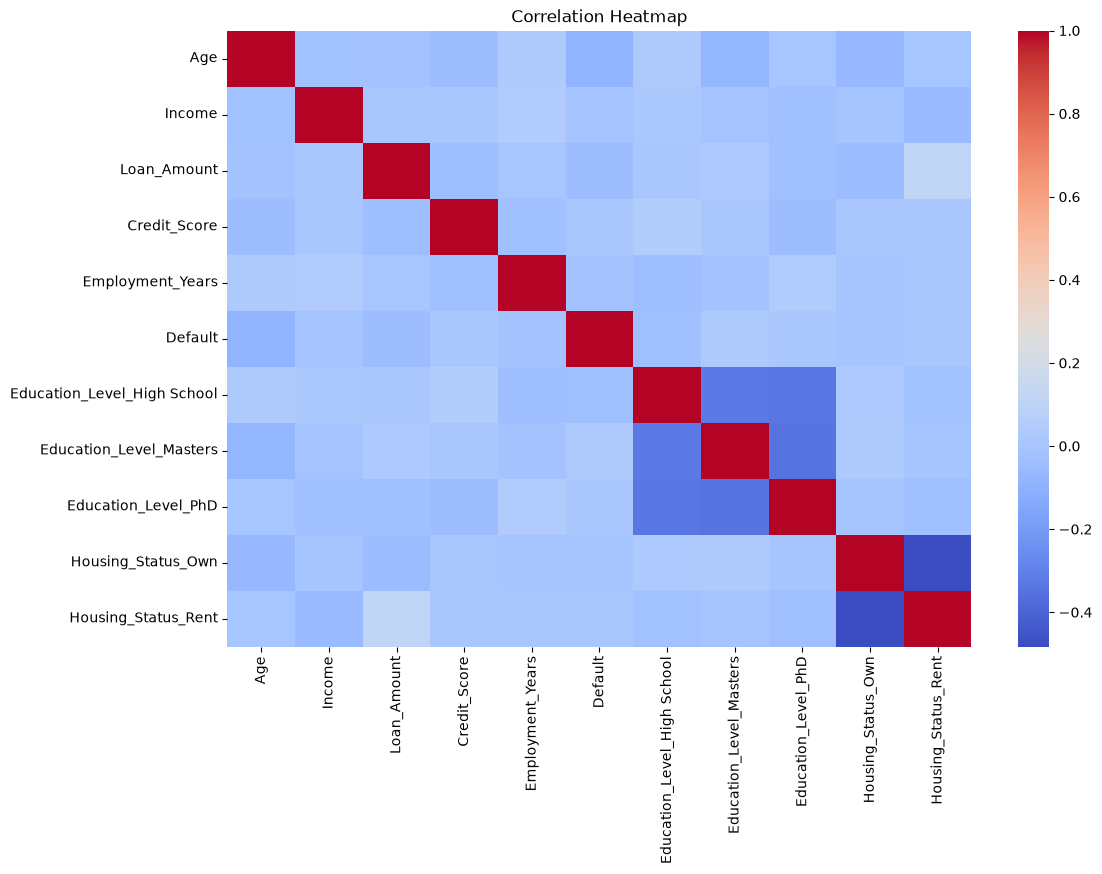

In [49]:
plt.figure(figsize=(12,8))
sns.heatmap(dp.corr(),cmap='coolwarm',annot=False)
plt.title("Correlation Heatmap")
plt.show()